 ## Домашнее задание Проверка гипотез

<div class="alert alert-info">
<b>Задание № 1</b>
    
Разработайте функцию для проверки нормальности распределения выборки данных, используя шаблон ниже. Вы можете использовать один из известных Вам статистических тестов.
</div>

In [1]:
# сразу подгружу
import numpy as np
import scipy.stats as stats
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.testing.print_coercion_tables import print_new_cast_table

In [2]:
def check_normality(data):
    '''
    на вход массив с данными, потом выполняется функция рассчета "Тест Д’Агостино и Пирсона"
    сравниваются Ассиметрия(скьнес/право-лево стор. распределение) и Эксцесс(острота пика и тяжесть хвостов) на графике
    на выходе мы получаем:
    stat - константу
    p_value - это вероятность получить такие же или более экстремальные данные исключительно за счет случайности, при условии,
    что нулевая гипотеза(h0) верна.

    h0 -- Данные распределены нормально
    h1 -- Данные распределены не нормально
    '''

    stat, p_value = stats.normaltest(data)  # "Тест Д’Агостино и Пирсона"

    alpha = 0.05  # уровень значимости

    if p_value < alpha:
        print("Отклоняем нулевую гипотезу >> Данные распределены не нормально")
    else:
        print("Не отклоняем нулевую гипотезу >> Данные распределены нормально")

<div class="alert alert-info">
<b>Задание № 2</b>

Даны две выборки роста мужчин и женщин.
- Докажите, используя `t-Тест Стьдента`, что различие между выборками незначительно, если уровень значимости равен $\alpha$ `= 0.001`.
- Покажите различия визуально
- Является ли результат полезным с практической точки зрения? Почему да или нет?
</div>

In [3]:
np.random.seed(42) #фиксация случайности

mens  = stats.norm.rvs(loc=171, scale=10, size=150000)  # Выборка мужчин со средним ростом 171
womens = stats.norm.rvs(loc=170, scale=10, size=150000)  # Выборка женщин со средним ростом 170

In [4]:
'''
h0 -- средний рост мужчин и женщин не отличается
h1 -- средний рост мужчин и женщин отличается
'''

stat, p_value = stats.ttest_ind(mens, womens)

alpha = 0.001

if p_value < alpha:
    print(f'Нулевая гипотеза отвергается')
else:
    print(f'Нулевая гипотеза принимается')

Нулевая гипотеза отвергается


p-value < 0.001 - Статистически различие между выборками обнаружено

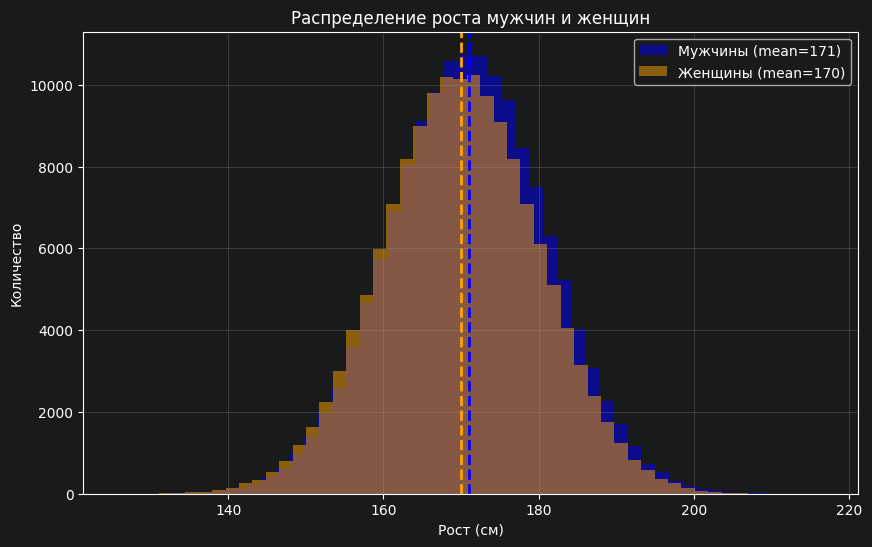

In [5]:
plt.figure(figsize=(10, 6))

# Строим гистограммы с прозрачностью (alpha=0.5)
plt.hist(mens, bins=50, alpha=0.5, label='Мужчины (mean=171)', color='blue')
plt.hist(womens, bins=50, alpha=0.5, label='Женщины (mean=170)', color='orange')

# Линии средних значений
plt.axvline(mens.mean(), color='blue', linestyle='--', linewidth=2)
plt.axvline(womens.mean(), color='orange', linestyle='--', linewidth=2)

plt.title('Распределение роста мужчин и женщин')
plt.xlabel('Рост (см)')
plt.ylabel('Количество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

- Если говорить о визуализации: визуализация является полезной с практической точки зрения.
Т.к. при расчете статистического теста мы просто можем работать с заданной гипотезой мы увидели разницу математически. В этом случае мы отвергли нулевую гипотезу о том, что "h0 - средний рост мужчин и женщин не отличается".

- Хотя на наглядном примере гистограммы мы видим, что у нас нас два распределения роста мужчин и женщин почти полностью перекрывают друг на друга, а разница между их средними значениями роста всего 1 см.


#### вывод:
- Графический метод наглядно показал, что различия между выборками незначительно.

<div class="alert alert-info">
<b>Задание № 3</b>

Специалист по кадрам, работающий в технологической компании, интересуется сверхурочным временем разных команд. Чтобы выяснить, есть ли разница между сверхурочной работой команды разработчиков программного обеспечения и группы тестирования, она случайным образом выбрала 17 сотрудников в каждой из двух команд и записала их среднее сверхурочное время за неделю в пересчете на час. Данные ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между переутомлением двух команд, используя уровень значимости 0,05. Прежде чем приступать к проверке гипотез, проверьте предположение нормальности.
</div>

In [6]:
test_team = [6.2, 7.1, 1.5, 2,3 , 2, 1.5, 6.1, 2.4, 2.3, 12.4, 1.8, 5.3, 3.1, 9.4, 2.3, 4.1]
developer_team = [2.3, 2.1, 1.4, 2.0, 8.7, 2.2, 3.1, 4.2, 3.6, 2.5, 3.1, 6.2, 12.1, 3.9, 2.2, 1.2 ,3.4]

In [17]:
# проверка нормальности данных тестом Шапиро
'''
h0: данные нормальны(не отличаются от нормальных)
h1: данные ненормальны
'''
alpha = 0.05
# Для команды тестировщиков
stat_test, p_val_test = stats.shapiro(test_team)

# Для команды разработчиков
stat_dev, p_val_dev = stats.shapiro(developer_team)

if p_val_test < alpha and p_val_dev < alpha:
    print(f'p-value тестировщиков: {p_val_test} \np-value разработчиков: {p_val_dev}, тк оба p-value < 0,05 отвергаем ho. \nДанные ненормальны')
else:
    print(f'Данные нормальны')


p-value тестировщиков: 0.004620073473463519 
p-value разработчиков: 0.000489113275069916, тк оба p-value < 0,05 отвергаем ho. 
Данные ненормальны


Раз мы поняли что данные не нормально, для проверки гипотезы о разнице переутомления джвух команды мы будем использовать непараметрический тест манна-Утни, вместо "t-тест Стьюдента":

In [21]:
# Проверка гипотезы "есть ли разница между переутомлением двух команд"
'''
h0: Статистически значимой разницы в переутомлении между командами не обнаружено.
h1: Разница в переутомлении между командами статистически значима!
'''

alpha = 0.05 # значимость
# Проверка непараметрическим тестом Манна-Уитни
stat, p_value = stats.mannwhitneyu(test_team, developer_team)

if p_value < alpha:
    print(f'p-value ({p_value:.4f}) < alpha ({alpha}). Отклоняем H0.\n'
        f'Разница в переутомлении между командами статистически значима!')
else:
    print(f'p-value ({p_value:.4f}) >= alpha ({alpha}). Не отклоняем H0.\n'
        f'Статистически значимой разницы в переутомлении между командами не обнаружено.')

p-value (0.8226) >= alpha (0.05). Не отклоняем H0.
Статистически значимой разницы в переутомлении между командами не обнаружено.


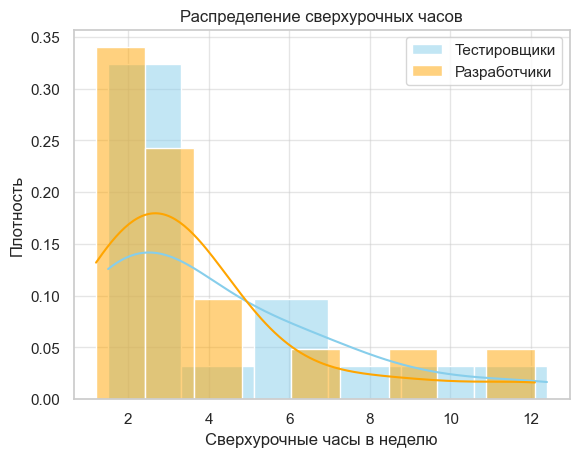

In [23]:
# Строим гистограммы с функциями плотности (KDE)
sns.histplot(
    test_team,
    color='skyblue',
    label='Тестировщики',
    kde=True,
    stat='density',
    alpha=0.5,
)
sns.histplot(
    developer_team,
    color='orange',
    label='Разработчики',
    kde=True,
    stat='density',
    alpha=0.5,
)

plt.title('Распределение сверхурочных часов')
plt.xlabel('Сверхурочные часы в неделю')
plt.ylabel('Плотность')
plt.legend()

plt.show()

Визуально обе гистограммы похожи(основная плотность сотрудников со сверхурочными расположена в диапазоне от 2 до 4 часов), распределения сверхурочных часов у разработчиков и тестировщиков обладают одинаковой формой.
- График не противоречит математическому подтверждению, что Статистически значимой разницы в переутомлении между командами не обнаружено.

<div class="alert alert-info">
<b>Задание № 4</b>

Педиатр хочет увидеть влияние потребления смеси на среднемесячную прибавку в весе у новорожденных. По этой причине она собрала данные из трех разных групп. Первая группа – дети исключительно грудного вскармливания, вторая группа – дети, которых кормят только смесью, и последняя группа – это дети, находящиеся на искусственном вскармливании и на грудном вскармливании. Эти данные приведены ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между среднемесячным приростом этих трех групп, используя уровень значимости 0,05. Если есть значительная разница, выполните дальнейший анализ, чтобы найти причину разницы.
</div>

In [25]:
only_breast = [794.1, 716.9, 993. , 724.7, 760.9, 908.2, 659.3 , 690.8, 768.7, 717.3 , 630.7, 729.5, 714.1, 810.3, 583.5, 679.9, 865.1]; # 17

only_formula = [898.8, 881.2, 940.2, 966.2, 957.5, 1061.7, 1046.2, 980.4, 895.6, 919.7, 1074.1, 952.5, 796.3, 859.6, 871.1 , 1047.5, 919.1 , 1160.5, 996.9]; # 19
both = [976.4, 656.4, 861.2, 706.8, 718.5, 717.1, 759.8, 894.6, 867.6, 805.6, 765.4, 800.3, 789.9, 875.3, 740. , 799.4, 790.3, 795.2 , 823.6, 818.7, 926.8, 791.7, 948.3]; # 23

In [37]:
#проверяем нормальность:
'''
h0 - вероятно распределение не отличается от нормального
h1 - вероятно распределение отличается от нормального
'''
stat, p_value_breast = stats.shapiro(only_breast)
stat, p_value_formula = stats.shapiro(only_formula)
stat, p_value_both = stats.shapiro(both)

print(f'сравнение нормальности в каждой группе p-value и Альфа = 0,05:\n'
      f'вскармливание:{p_value_breast:.2f};\n'
      f'смесь: {p_value_formula:.2f};\n'
      f'гибрид:{p_value_both:.2f};')


сравнение нормальности в каждой группе p-value и Альфа = 0,05:
вскармливание:0.47;
смесь: 0.89;
гибрид:0.80;


Т.к. значения больше 0,05 данные вероятно не отличаются от нормальных. Проведем сравнение 3х групп:

In [38]:
# проведем сравнение трех групп, на гомогенность дисперсий:
'''
h0 дисперсия не отличается(гомогенна),
h1 - негомогенна
'''
stat, p_value_levene = stats.levene(only_breast, only_formula, both)
print(f'p-value теста Левене: {p_value_levene:.4f}')

p-value теста Левене: 0.7673


дисперсия гомогенна, проводим дисперсный анализ:


In [43]:
# ANOVA.
'''
h0: средняя масса в весе имеет статистически НЕ значимые различая
h1: средняя масса в весе имеет статистически значимые различая
'''
stat_anova, p_val_anova = stats.f_oneway(only_breast, only_formula, both)
alpha = 0.05

if p_val_anova < alpha:
    print(f'p-value ANOVA: {p_val_anova:.4f} \nсредняя масса в весе имеет статистически значимые различая')
else:
    print(f'p-value ANOVA: {p_val_anova:.4f} \nсредняя масса в весе имеет статистически НЕ значимые различая')

p-value ANOVA: 0.0000 
средняя масса в весе имеет статистически значимые различая


На первом этапе был проведен однофакторный дисперсионный анализ (ANOVA), который выявил статистически значимые различия между группами (\(p-value < 0.05\))
Для выявления причин, проведем тест сравнений Тьюки

In [44]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Формируем объединенный DataFrame для теста Тьюки
df = pd.DataFrame(
    {
        'weight': only_breast + only_formula + both,
        'group': (
            ['breast'] * len(only_breast)
            + ['formula'] * len(only_formula)
            + ['both'] * len(both)
        ),
    }
)

# Запускаем тест Тьюки
tukey = pairwise_tukeyhsd(
    endog=df['weight'], groups=df['group'], alpha=0.05
)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1  group2 meandiff p-adj    lower    upper   reject
--------------------------------------------------------
  both  breast -60.1286 0.0995 -129.1485   8.8912  False
  both formula 149.2636    0.0   82.3651 216.1621   True
breast formula 209.3923    0.0  137.3508 281.4337   True
--------------------------------------------------------


#### вывод:
- Однофакторный дисперсный анализ ANOVA показал статистические различия  между типами питания на среднемесячный прирост веса в группах p-value < 0.05
- Пост-хок анализ Тьюки выявил, что главный источник различий — группа искусственного вскармливания "formula". Дети в этой группе демонстрируют гораздо больший прирост в весе между другими группами.
- Между группами грудного и смешанного вскармливания статистически значимой разницы не обнаружено p = 0.0995

<div class="alert alert-info">
<b>Задание № 5 (Опционально) </b>

Аналитик финансовой инвестиционной компании интересуется взаимосвязью между полом и склонностью к риску. Из базы данных была взята случайная выборка из 660 клиентов. Клиенты в выборке были классифицированы в соответствии с их полом и склонностью к риску. Результат приведен в следующей таблице.
    
Проверьте гипотезу о том, что склонность к риску клиентов этой компании не зависит от их пола. Используйте α = 0.01.    
</div>

In [ ]:
contingency_table = pd.DataFrame(
    [
        [53, 23, 30, 36, 88],
        [71, 48, 51, 57, 203]
    ],
    #columns = ['Machine Learning', 'Data Science', 'Analytics'],
    index = ['Ж', 'М'])

print('Уровень риска')
print(contingency_table)

<div class="alert alert-info">
<b>Задание № 6 (Опционально)</b>

Компания электронной коммерции регулярно размещает рекламу своих кампаний на YouTube, Instagram и Facebook. Однако новому менеджеру было любопытно, есть ли разница между количеством клиентов, привлеченных этими платформами. Поэтому она начала использовать Adjust — приложение, позволяющее узнать, откуда приходят ваши пользователи. Ежедневные цифры, сообщаемые Adjust для каждой платформы, приведены ниже.
    
В соответствии с этой информацией проведите проверку гипотез, чтобы проверить, есть ли разница между средним числом привлеченных клиентов на этих трех платформах с использованием уровня значимости 0,05. Если есть значительная разница, выполните дальнейший анализ, чтобы найти причину разницы. Прежде чем приступать к проверке гипотез, проверьте соответствующие предположения.
</div>

In [ ]:
youtube=[1913, 1879, 1939, 2146, 2040, 2127, 2122, 2156, 2036, 1974, 1956, 2146, 2151, 1943, 2125]
instagram = [2305., 2355., 2203., 2231., 2185., 2420., 2386., 2410., 2340., 2349., 2241., 2396., 2244., 2267., 2281.]
facebook = [2133., 2522., 2124., 2551., 2293., 2367., 2460., 2311., 2178., 2113., 2048., 2443., 2265., 2095., 2528.]

# **Примечание:**

Домашнее задание сдается ссылкой [Google Colab](https://colab.research.google.com/). Мы не сможем проверить его или помочь, если вы пришлете:

*   файлы;
*   архивы;
*   скриншоты кода.

Все обсуждения и консультации по выполнению домашнего задания ведутся только на соответствующем канале в Discord.

**Как правильно задавать вопросы аспирантам, преподавателям и коллегам:**

Прежде чем задать вопрос, попробуйте найти ответ в интернете. Навык самостоятельного поиска информации — один из важнейших. Каждый практикующий специалист любого уровня делает это ежедневно.

Сформулируйте вопрос по алгоритму:

1.   Что я делаю?
2.   Какого результата я ожидаю?
3.   Как фактический результат отличается от ожидаемого?
4.   Что я уже попробовал сделать, чтобы исправить проблему?

По возможности прикрепите к вопросу скриншоты либо ссылки на код. Не выкладывайте все решение, оставляйте только проблемный и воспроизводимый участок кода.